In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


In [36]:
IMG_DIR = '/content/dataset/celeba/images'
ATTR_FILE = '/content/dataset/celeba/list_attr_celeba_500.csv'

batch_size = 32
image_size = 128
epochs = 5
device = torch.device('cpu')

In [37]:
df = pd.read_csv(ATTR_FILE)
df.head()

df.replace(-1, 0, inplace=True)

Target_Attr = 'Smiling'

In [38]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
2,000003.jpg,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,000004.jpg,0,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
4,000005.jpg,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


In [39]:
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42
)

In [71]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [77]:
class CelebADataset(Dataset):

  def __init__(self, df, IMG_DIR, transform=None):
    self.df = df
    self.IMG_DIR = IMG_DIR
    self.transform = transform


  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_name = self.df.iloc[idx]['image_id']
    label = self.df.iloc[idx]['Smiling']

    img_path = os.path.join(self.IMG_DIR, img_name)
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)
      print("hi")

    label = torch.tensor(label).float()

    return image, label

In [78]:
train_dataset = CelebADataset(train_df, IMG_DIR, transform)
val_dataset = CelebADataset(val_df, IMG_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [87]:
from torch.nn.modules.conv import Conv2d
class CelebACNN(nn.Module):

  def __init__(self):
    super(CelebACNN, self).__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv2d(3, 32, 3,  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64,3,  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128,3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256,3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.fc_layers = nn.Sequential(

        nn.Flatten(),
        nn.Linear(256 * 8 * 8, 512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    print("Input:", x.shape)

    x = self.conv_layers(x)
    print("Input:", x.shape)

    x = self.fc_layers(x)

    return x

In [88]:
model = CelebACNN().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [97]:
train_losses = []
for epoch in range(epochs):
  model.train()
  train_loss = 0


  for images, labels in train_loader:
    images = images.to(device)
    label = labels.to(device).unsqueeze(1)

    optimizer.zero_grad()

    outputs = model(images)

    labels = labels.unsqueeze(1)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    train_loss = train_loss + loss.item()

  epoch_loss = train_loss / len(train_loader)

  train_losses.append(epoch_loss)
  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader)}")

  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            preds = (outputs > 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

  acc = correct / total

  print("Validation Accuracy:", acc)


hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256, 8, 8])
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256, 8, 8])
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256, 8, 8])
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256, 8, 8])
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256, 8, 8])
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Input: torch.Size([32, 3, 128, 128])
Input: torch.Size([32, 256,

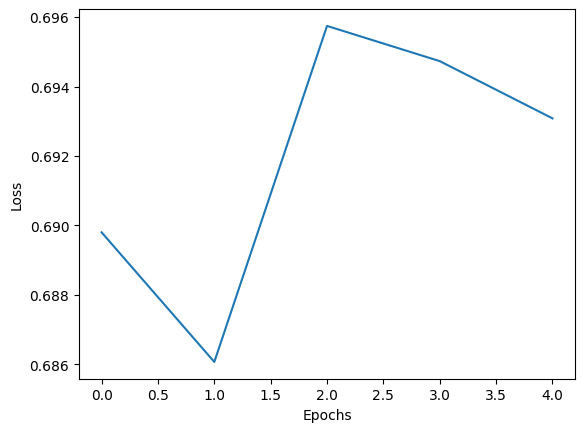

In [98]:
import matplotlib.pyplot as plt


plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()